# 11 Taxa

In [27]:
import pandas as pd

In [28]:
df = pd.read_csv("results_11-taxa-weighted-quartets.csv")

In [29]:
tree1 = "(((((1,2),3),4),((((5,6),(7,8)),9),10)),11);"
tree2 = "(((((1.1,2.2),3.3),4.4),((((5.5,6.6),(7.7,8.8)),9.9),10.10)),11.11);"

df["model_tree"] = [tree1 if i < 100 else tree2 for i in range(len(df))]

In [30]:
import sys
sys.path.insert(0, ".")
sys.setrecursionlimit(10_000_000)
import dendropy
from robinson_foulds import robinson_foulds_distance

def rf_rate(newick1, newick2):
    tns = dendropy.TaxonNamespace()
    t1 = dendropy.Tree.get(data=newick1, schema="newick", taxon_namespace=tns)
    t2 = dendropy.Tree.get(data=newick2, schema="newick", taxon_namespace=tns)
    return robinson_foulds_distance(t1, t2)

df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)

In [31]:
wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()

print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 3
QUBO better : 4
Draws       : 193


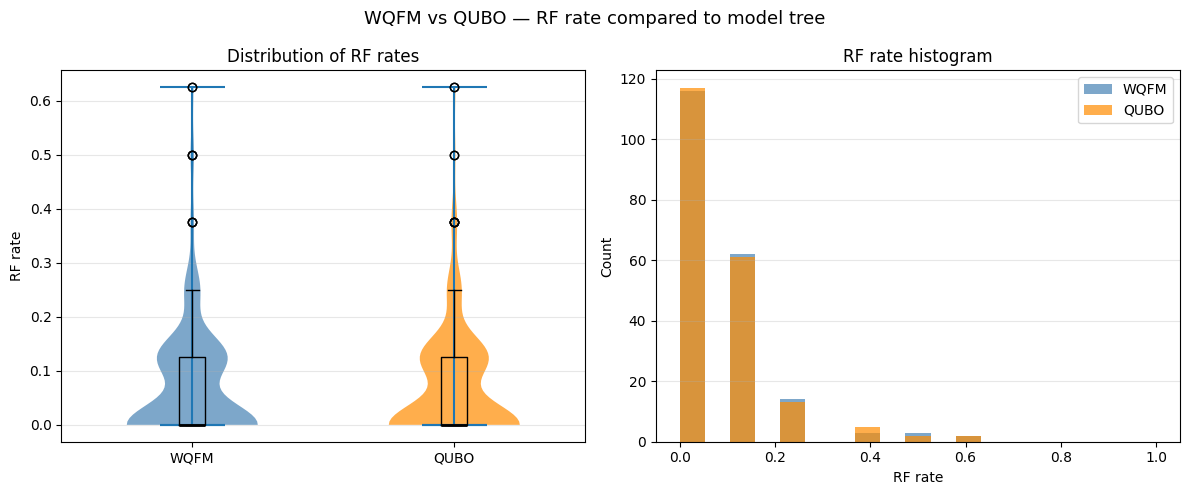

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Violin + box overlay ---
data = [df["rf_rate_wqfm"], df["rf_rate_qubo"]]
parts = axes[0].violinplot(data, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], ["steelblue", "darkorange"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].boxplot(data, positions=[1, 2], widths=0.1, patch_artist=False,
                medianprops=dict(color="black", linewidth=2))
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["WQFM", "QUBO"])
axes[0].set_ylabel("RF rate")
axes[0].set_title("Distribution of RF rates")
axes[0].grid(True, alpha=0.3, axis="y")

# --- Right: Histogram ---
bins = np.linspace(0, 1, 20)
axes[1].hist(df["rf_rate_wqfm"], bins=bins, alpha=0.7, label="WQFM", color="steelblue")
axes[1].hist(df["rf_rate_qubo"], bins=bins, alpha=0.7, label="QUBO", color="darkorange")
axes[1].set_xlabel("RF rate")
axes[1].set_ylabel("Count")
axes[1].set_title("RF rate histogram")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("WQFM vs QUBO — RF rate compared to model tree", fontsize=13)
plt.tight_layout()
plt.show()

# 15 Taxa

In [33]:
df = pd.read_csv('results_15-taxa-weighted-quartets.csv')

In [34]:
model_tree = "((((((((((((((A,B),C),D),E),F),G),H),I),J),K),L),M),N),O);"
df["model_tree"] = model_tree
df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)


In [35]:
wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()

print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 3
QUBO better : 5
Draws       : 52


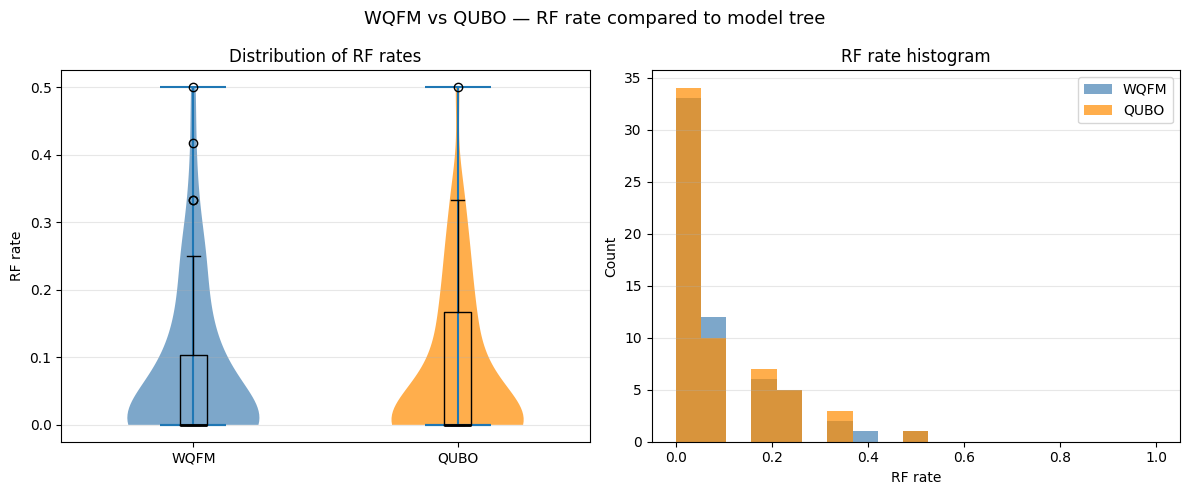

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Violin + box overlay ---
data = [df["rf_rate_wqfm"], df["rf_rate_qubo"]]
parts = axes[0].violinplot(data, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], ["steelblue", "darkorange"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].boxplot(data, positions=[1, 2], widths=0.1, patch_artist=False,
                medianprops=dict(color="black", linewidth=2))
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["WQFM", "QUBO"])
axes[0].set_ylabel("RF rate")
axes[0].set_title("Distribution of RF rates")
axes[0].grid(True, alpha=0.3, axis="y")

# --- Right: Histogram ---
bins = np.linspace(0, 1, 20)
axes[1].hist(df["rf_rate_wqfm"], bins=bins, alpha=0.7, label="WQFM", color="steelblue")
axes[1].hist(df["rf_rate_qubo"], bins=bins, alpha=0.7, label="QUBO", color="darkorange")
axes[1].set_xlabel("RF rate")
axes[1].set_ylabel("Count")
axes[1].set_title("RF rate histogram")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("WQFM vs QUBO — RF rate compared to model tree", fontsize=13)
plt.tight_layout()
plt.show()

# 37 Taxa


In [37]:
df = pd.read_csv('results_37-taxa-weighted-quartets.csv')

model_tree = "(GAL,(ORN,(((((PRO,LOX),ECH),(DAS,CHO)),((((OTO,MIC),((CAL,((PON,(GOR,(HOM,PAN))),NEW)),TAR)),(((OCH,ORY),(SPE,((DIP,(RAT,MUS)),CAV))),TUP)),(((PTE,MYO),((EQU,(FEL,CAN)),((SUS,(BOS,TUR)),VIC))),(ERI,SOR)))),(MON,MAC))));"
df["model_tree"] = model_tree

df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)

wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()

print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 3
QUBO better : 1
Draws       : 94


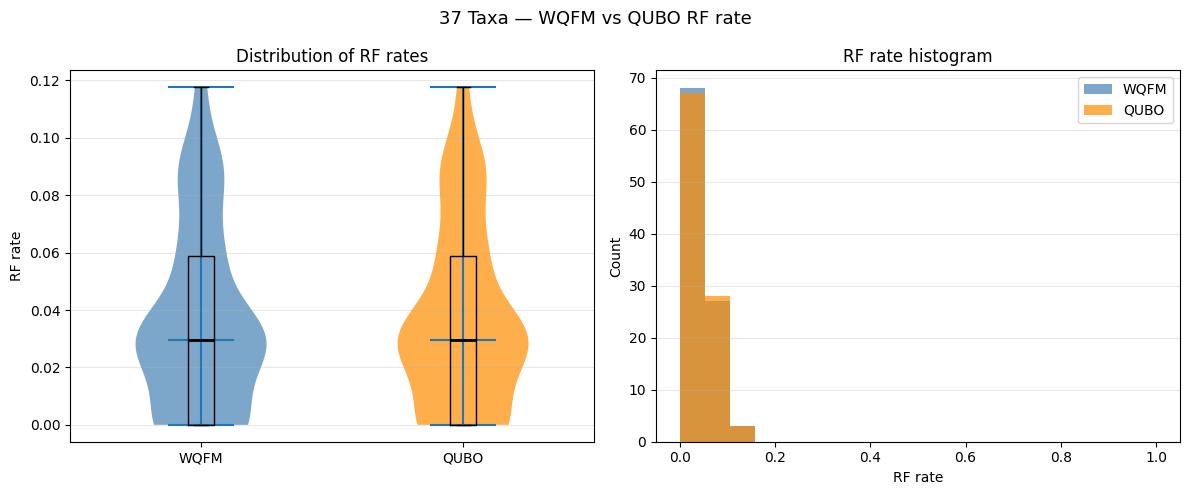

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data = [df["rf_rate_wqfm"], df["rf_rate_qubo"]]
parts = axes[0].violinplot(data, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], ["steelblue", "darkorange"]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[0].boxplot(data, positions=[1, 2], widths=0.1, patch_artist=False,
                medianprops=dict(color="black", linewidth=2))
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["WQFM", "QUBO"])
axes[0].set_ylabel("RF rate"); axes[0].set_title("Distribution of RF rates")
axes[0].grid(True, alpha=0.3, axis="y")

bins = np.linspace(0, 1, 20)
axes[1].hist(df["rf_rate_wqfm"], bins=bins, alpha=0.7, label="WQFM", color="steelblue")
axes[1].hist(df["rf_rate_qubo"], bins=bins, alpha=0.7, label="QUBO", color="darkorange")
axes[1].set_xlabel("RF rate"); axes[1].set_ylabel("Count")
axes[1].set_title("RF rate histogram"); axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("37 Taxa — WQFM vs QUBO RF rate", fontsize=13)
plt.tight_layout(); plt.show()

# 48 Taxa


In [39]:
df= pd.read_csv('results_48-taxa-weighted-quartets.csv')
model_tree ="(STRCA,(TINMA,((((CUCCA,(TAUER,CHLUN)),((CAPCA,(CALAN,CHAPE)),(((TYTAL,(CATAU,(HALLE,HALAL))),((COLST,(LEPDI,(APAVI,(BUCRH,(PICPU,MERNU))))),(CARCR,(FALPE,((ACACH,(MANVI,(CORBR,(TAEGU,GEOFO)))),(MELUN,NESNO)))))),(OPHHO,(((GAVST,((PHACA,(NIPNI,(PELCR,EGRGA))),(FULGL,(PYGAD,APTFO)))),(PHALE,EURHE)),(BALRE,CHAVO)))))),((COLLI,(MESUN,PTEGU)),(PHORU,PODCR))),((MELGA,GALGA),ANAPL))));"
df["model_tree"] = model_tree
df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)
wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()
print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 0
QUBO better : 1
Draws       : 9


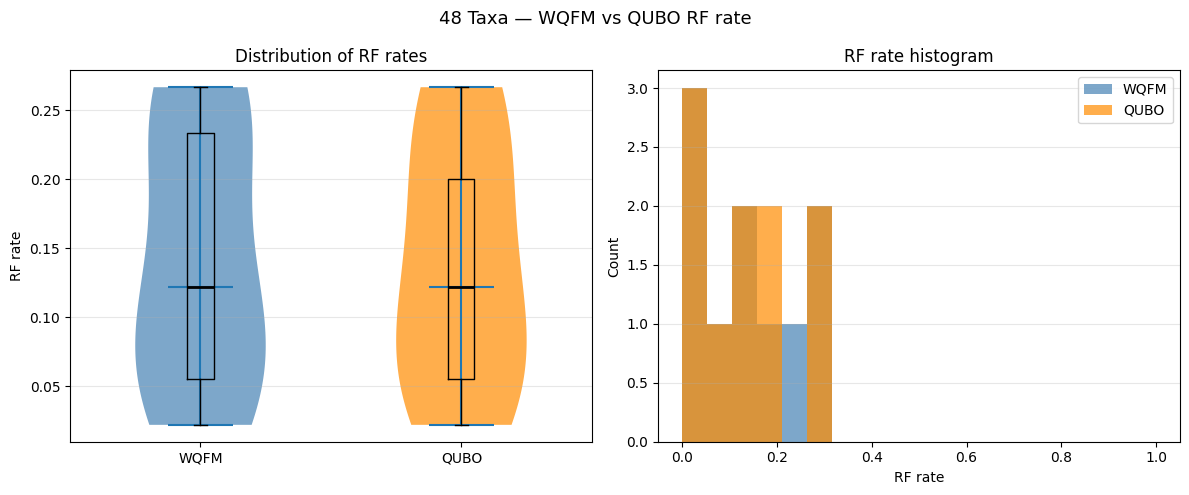

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data = [df["rf_rate_wqfm"], df["rf_rate_qubo"]]
parts = axes[0].violinplot(data, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], ["steelblue", "darkorange"]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[0].boxplot(data, positions=[1, 2], widths=0.1, patch_artist=False,
                medianprops=dict(color="black", linewidth=2))
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["WQFM", "QUBO"])
axes[0].set_ylabel("RF rate"); axes[0].set_title("Distribution of RF rates")
axes[0].grid(True, alpha=0.3, axis="y")

bins = np.linspace(0, 1, 20)
axes[1].hist(df["rf_rate_wqfm"], bins=bins, alpha=0.7, label="WQFM", color="steelblue")
axes[1].hist(df["rf_rate_qubo"], bins=bins, alpha=0.7, label="QUBO", color="darkorange")
axes[1].set_xlabel("RF rate"); axes[1].set_ylabel("Count")
axes[1].set_title("RF rate histogram"); axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("48 Taxa — WQFM vs QUBO RF rate", fontsize=13)
plt.tight_layout(); plt.show()

# Combined Results

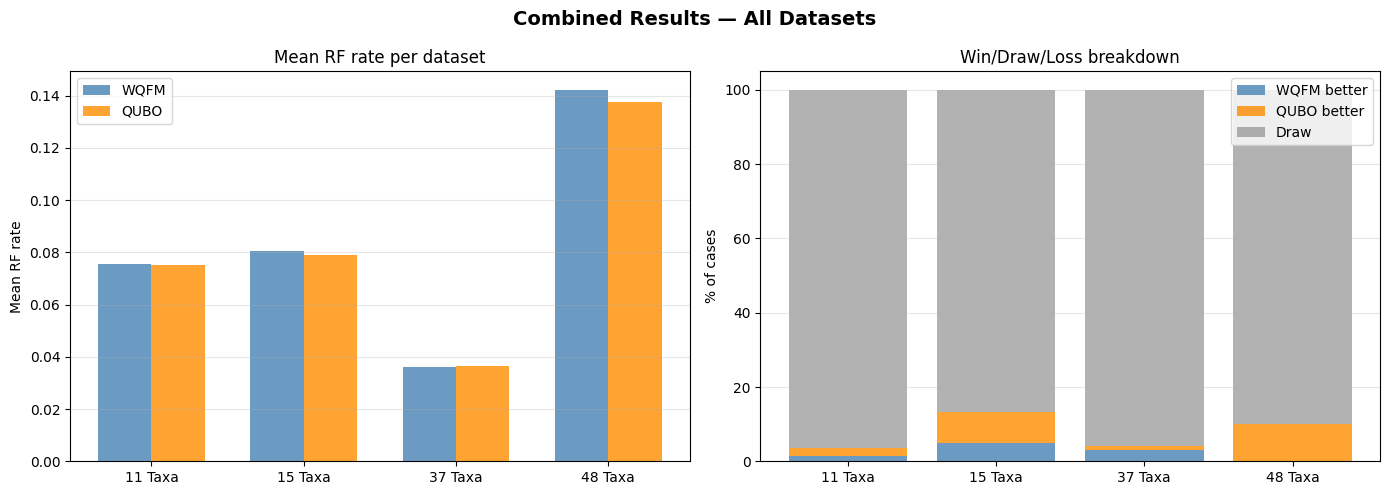

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Rebuild all 4 datasets ---
datasets = {}

# 11 taxa
d = pd.read_csv("results_11-taxa-weighted-quartets.csv")
tree1 = "(((((1,2),3),4),((((5,6),(7,8)),9),10)),11);"
tree2 = "(((((1.1,2.2),3.3),4.4),((((5.5,6.6),(7.7,8.8)),9.9),10.10)),11.11);"
d["model_tree"] = [tree1 if i < 100 else tree2 for i in range(len(d))]
d["rf_rate_wqfm"] = d.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
d["rf_rate_qubo"] = d.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)
datasets["11 Taxa"] = d

# 15 taxa
d = pd.read_csv("results_15-taxa-weighted-quartets.csv")
d["model_tree"] = "((((((((((((((A,B),C),D),E),F),G),H),I),J),K),L),M),N),O);"
d["rf_rate_wqfm"] = d.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
d["rf_rate_qubo"] = d.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)
datasets["15 Taxa"] = d

# 37 taxa
d = pd.read_csv("results_37-taxa-weighted-quartets.csv")
d["model_tree"] = "(GAL,(ORN,(((((PRO,LOX),ECH),(DAS,CHO)),((((OTO,MIC),((CAL,((PON,(GOR,(HOM,PAN))),NEW)),TAR)),(((OCH,ORY),(SPE,((DIP,(RAT,MUS)),CAV))),TUP)),(((PTE,MYO),((EQU,(FEL,CAN)),((SUS,(BOS,TUR)),VIC))),(ERI,SOR)))),(MON,MAC))));"
d["rf_rate_wqfm"] = d.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
d["rf_rate_qubo"] = d.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)
datasets["37 Taxa"] = d

# 48 taxa
d = pd.read_csv("results_48-taxa-weighted-quartets.csv")
d["model_tree"] = "(STRCA,(TINMA,((((CUCCA,(TAUER,CHLUN)),((CAPCA,(CALAN,CHAPE)),(((TYTAL,(CATAU,(HALLE,HALAL))),((COLST,(LEPDI,(APAVI,(BUCRH,(PICPU,MERNU))))),(CARCR,(FALPE,((ACACH,(MANVI,(CORBR,(TAEGU,GEOFO)))),(MELUN,NESNO)))))),(OPHHO,(((GAVST,((PHACA,(NIPNI,(PELCR,EGRGA))),(FULGL,(PYGAD,APTFO)))),(PHALE,EURHE)),(BALRE,CHAVO)))))),((COLLI,(MESUN,PTEGU)),(PHORU,PODCR))),((MELGA,GALGA),ANAPL))));"
d["rf_rate_wqfm"] = d.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
d["rf_rate_qubo"] = d.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)
datasets["48 Taxa"] = d

labels = list(datasets.keys())

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Mean RF rate bar chart
wqfm_means = [datasets[l]["rf_rate_wqfm"].mean() for l in labels]
qubo_means  = [datasets[l]["rf_rate_qubo"].mean()  for l in labels]
x = np.arange(len(labels)); w = 0.35
axes[0].bar(x - w/2, wqfm_means, w, label="WQFM", color="steelblue", alpha=0.8)
axes[0].bar(x + w/2, qubo_means,  w, label="QUBO", color="darkorange", alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Mean RF rate")
axes[0].set_title("Mean RF rate per dataset")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

# 2) Wins/draws/losses stacked bar
wqfm_wins = [(datasets[l]["rf_rate_wqfm"] <  datasets[l]["rf_rate_qubo"]).sum() for l in labels]
qubo_wins  = [(datasets[l]["rf_rate_qubo"] <  datasets[l]["rf_rate_wqfm"]).sum() for l in labels]
draws      = [(datasets[l]["rf_rate_wqfm"] == datasets[l]["rf_rate_qubo"]).sum() for l in labels]
totals     = [len(datasets[l]) for l in labels]
wqfm_pct   = [w/t*100 for w, t in zip(wqfm_wins, totals)]
qubo_pct   = [w/t*100 for w, t in zip(qubo_wins,  totals)]
draw_pct   = [w/t*100 for w, t in zip(draws,       totals)]

axes[1].bar(x, wqfm_pct, label="WQFM better", color="steelblue", alpha=0.8)
axes[1].bar(x, qubo_pct, bottom=wqfm_pct, label="QUBO better", color="darkorange", alpha=0.8)
axes[1].bar(x, draw_pct, bottom=[a+b for a,b in zip(wqfm_pct, qubo_pct)], label="Draw", color="gray", alpha=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel("% of cases")
axes[1].set_title("Win/Draw/Loss breakdown")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Combined Results — All Datasets", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

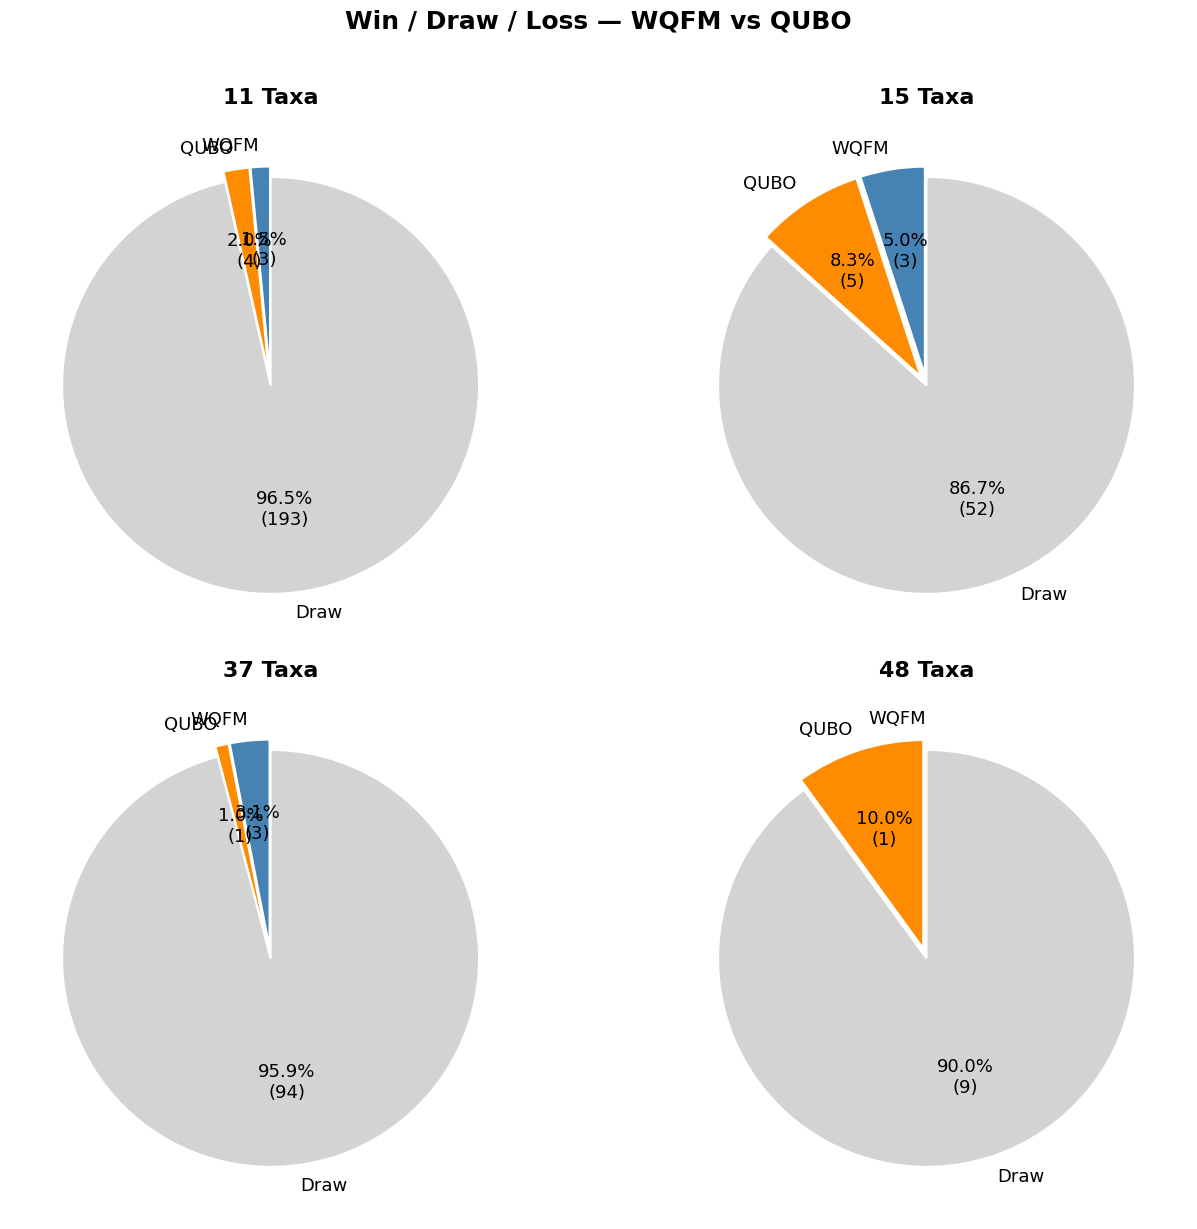

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, lbl in zip(axes, labels):
    d = datasets[lbl]
    wqfm_w = (d["rf_rate_wqfm"] < d["rf_rate_qubo"]).sum()
    qubo_w = (d["rf_rate_qubo"] < d["rf_rate_wqfm"]).sum()
    draw   = (d["rf_rate_wqfm"] == d["rf_rate_qubo"]).sum()

    sizes   = [wqfm_w, qubo_w, draw]
    clrs    = ["steelblue", "darkorange", "lightgray"]
    explode = [0.05, 0.05, 0]

    ax.pie(
        sizes, labels=["WQFM", "QUBO", "Draw"],
        autopct=lambda p: f"{p:.1f}%\n({int(round(p*sum(sizes)/100))})" if p > 0 else "",
        colors=clrs, explode=explode, startangle=90,
        textprops={"fontsize": 13},
        wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
    )
    ax.set_title(lbl, fontsize=16, fontweight="bold", pad=15)

plt.suptitle("Win / Draw / Loss — WQFM vs QUBO", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()